<a href="https://colab.research.google.com/github/hidayat12345-gethub/app/blob/main/student_performance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import numpy as np
import pandas as pd


In [5]:
df=pd.read_csv('/content/drive/MyDrive/Student_Performance.csv')


In [6]:
print(df.head(20))

    Hours Studied  Previous Scores Extracurricular Activities  Sleep Hours  \
0               7               99                        Yes            9   
1               4               82                         No            4   
2               8               51                        Yes            7   
3               5               52                        Yes            5   
4               7               75                         No            8   
5               3               78                         No            9   
6               7               73                        Yes            5   
7               8               45                        Yes            4   
8               5               77                         No            8   
9               4               89                         No            4   
10              8               91                         No            4   
11              8               79                         No   

In [7]:
df.isnull().sum()

,0
Hours Studied,0
Previous Scores,0
Extracurricular Activities,0
Sleep Hours,0
Sample Question Papers Practiced,0
Performance Index,0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [9]:
df['Extracurricular Activities'] = df['Extracurricular Activities'].map({'Yes': 1, 'No': 0})
display(df.head())

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0


In [11]:
print(df['Extracurricular Activities'].unique())

[1 0]


In [12]:
# Reload the DataFrame to get the original 'Extracurricular Activities' column
df = pd.read_csv('/content/drive/MyDrive/Student_Performance.csv')

# Clean the 'Extracurricular Activities' column: strip spaces and convert to lowercase
df['Extracurricular Activities'] = df['Extracurricular Activities'].str.strip().str.lower()

# Now apply the mapping
df['Extracurricular Activities'] = df['Extracurricular Activities'].map({'yes': 1, 'no': 0})

display(df.head())

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0


In [13]:
x=df.drop(['Performance Index'],axis=1)
y=df['Performance Index']

In [14]:
y

,Performance Index
0,91.0
1,65.0
2,45.0
3,36.0
4,66.0
...,...
9995,23.0
9996,58.0
9997,74.0
9998,95.0


In [16]:
#import train test function
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=2)
#x_train.head(23)

In [17]:
#train model import linearregression
from sklearn.linear_model import LinearRegression
model=LinearRegression()

In [18]:
#train model
model.fit(x_train,y_train)

LinearRegression()

In [19]:
model.score(x_train,y_train)

0.9886611170188228

In [23]:
y_predict=model.predict(x_test)
print(y_predict)

[28.09141683 35.39557867 80.43795479 ... 45.01315301 30.31243483
 68.64738321]


In [25]:
print([y_test,y_predict])

[7878    26.0
3224    34.0
1919    80.0
4432    62.0
4835    83.0
        ... 
9073    91.0
8584    15.0
5390    44.0
5092    31.0
2964    67.0
Name: Performance Index, Length: 2000, dtype: float64, array([28.09141683, 35.39557867, 80.43795479, ..., 45.01315301,
       30.31243483, 68.64738321])]


In [31]:
comparison_df = pd.DataFrame({'Actual': y_test.reset_index(drop=True), 'Predicted': y_predict})
display(comparison_df.head())

,Actual,Predicted
0,26.0,28.091417
1,34.0,35.395579
2,80.0,80.437955
3,62.0,65.792531
4,83.0,81.933145


In [29]:
model.predict([[8,87,1,8,6]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([83.00189739])

In [32]:
from ipywidgets import widgets, VBox, HBox, Layout, Output
from IPython.display import display
import pandas as pd
import numpy as np

## <font color="blue">Student Performance Predictor</font>

Welcome! Please use the controls below to enter the student's information. The model will then predict their 'Performance Index'. Ensure your inputs are within the specified ranges.

In [69]:
# Install Plotly for interactive visualizations if not already installed
%pip install plotly --quiet

## <font color="#6A5ACD">📊 Model Information Panel</font>

Here's a summary of the trained model's performance and characteristics, providing key insights into its reliability and how it utilizes the input features.

In [70]:
# Display Model Information
print(f"<span style='font-weight: bold; color: #00BFFF;'>Model Type:</span> Linear Regression")
print(f"<span style='font-weight: bold; color: #00BFFF;'>Training R² Score:</span> {model.score(x_train, y_train):.4f}")
print(f"<span style='font-weight: bold; color: #00BFFF;'>Test R² Score:</span> {model.score(x_test, y_test):.4f}")
print(f"<span style='font-weight: bold; color: #00BFFF;'>Mean Absolute Error (MAE):</span> {mae:.2f}")
print(f"<span style='font-weight: bold; color: #00BFFF;'>Root Mean Squared Error (RMSE):</span> {rmse:.2f}")
print(f"<span style='font-weight: bold; color: #00BFFF;'>Number of Features:</span> {len(feature_names)}")
print(f"<span style='font-weight: bold; color: #00BFFF;'>Training Samples:</span> {len(x_train)}")


<span style='font-weight: bold; color: #00BFFF;'>Model Type:</span> Linear Regression
<span style='font-weight: bold; color: #00BFFF;'>Training R² Score:</span> 0.9887
<span style='font-weight: bold; color: #00BFFF;'>Test R² Score:</span> 0.9891
<span style='font-weight: bold; color: #00BFFF;'>Mean Absolute Error (MAE):</span> 1.59
<span style='font-weight: bold; color: #00BFFF;'>Root Mean Squared Error (RMSE):</span> 2.02
<span style='font-weight: bold; color: #00BFFF;'>Number of Features:</span> 5
<span style='font-weight: bold; color: #00BFFF;'>Training Samples:</span> 8000


## <font color="#6A5ACD">📈 Analytics Dashboard</font>

Explore the relationships and distributions within the student performance data through these interactive charts.

/tmp/ipykernel_503/3641484348.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


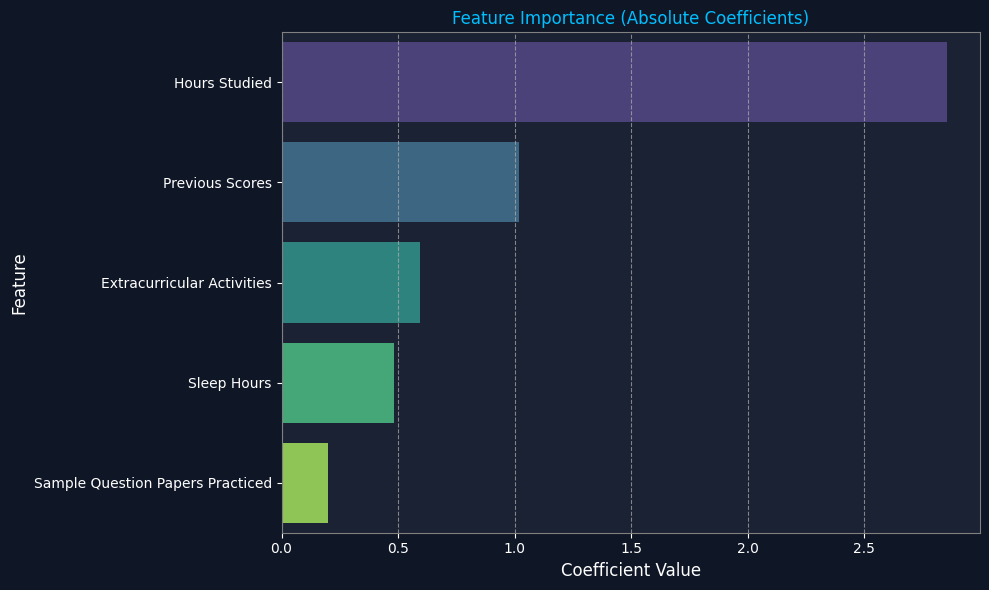

In [62]:
# 1. Feature Importance Bar Chart (Modified to save figure)
fig1 = plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Feature Importance (Absolute Coefficients)', fontsize=16)
plt.xlabel('Coefficient Value', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Apply custom dark theme for Matplotlib
fig1.patch.set_facecolor('#0F1626') # Deep Navy background for the figure
plt.gca().set_facecolor('#1A2233') # Card background for the axes area
plt.tick_params(colors='white') # White ticks
plt.xlabel(plt.gca().get_xlabel(), color='white') # White x-axis label
plt.ylabel(plt.gca().get_ylabel(), color='white') # White y-axis label
plt.title(plt.gca().get_title(), color='#00BFFF') # Blue title
plt.gca().spines['bottom'].set_color('gray')
plt.gca().spines['left'].set_color('gray')
plt.gca().spines['top'].set_color('gray')
plt.gca().spines['right'].set_color('gray')

plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.savefig('feature_importance.png', facecolor=fig1.get_facecolor(), bbox_inches='tight')
plt.show(fig1) # Display the figure
plt.close(fig1) # Close the figure to free up memory


## <font color="#00BFFF">Futuristic Dashboard Styling</font>

Applying custom CSS to enhance the visual appeal of the dashboard elements.

In [59]:
from IPython.display import HTML, display

# Custom CSS for a futuristic, dark theme
custom_css = """
<style>
    body { /* Target the general notebook body for overall theme */
        background-color: #0F1626 !important; /* Deep Navy */
        color: #F8F8F8 !important; /* White */
        font-family: 'Segoe UI', 'Roboto', 'Helvetica Neue', Arial, sans-serif !important;
    }

    /* Style for markdown headers */
    .jp-RenderedMarkdown h1, .jp-RenderedMarkdown h2, .jp-RenderedMarkdown h3, .jp-RenderedMarkdown h4, .jp-RenderedMarkdown h5, .jp-RenderedMarkdown h6 {
        color: #00BFFF !important; /* Electric Blue for titles */
    }

    /* Style for ipywidgets containers */
    .jupyter-widgets-view {
        background-color: #1A2233 !important; /* Slightly lighter deep navy for cards */
        border-radius: 10px;
        padding: 15px;
        margin-bottom: 20px;
        box-shadow: 0 4px 8px rgba(0, 0, 0, 0.4);
        border: 1px solid #00BFFF;
    }

    /* Style for widget labels */
    .widget-label {
        color: #ADD8E6 !important; /* Light blue for labels */
        font-weight: bold;
        font-size: 1.1em;
    }

    /* Style for IntSlider */
    .widget-slider .ui-slider-range {
        background: #00BFFF !important; /* Electric Blue slider track */
    }
    .widget-slider .ui-slider-handle {
        background: #9D2CE5 !important; /* Purple handle */
        border: 1px solid #00BFFF;
        border-radius: 50%;
    }

    /* Style for ToggleButtons */
    .widget-togglebuttons .widget-button {
        background-color: #2D3950 !important; /* Darker background for buttons */
        color: #F8F8F8 !important;
        border: 1px solid #00BFFF;
        border-radius: 5px;
        transition: all 0.3s ease;
    }
    .widget-togglebuttons .widget-button.mod-info {
        background-color: #00BFFF !important; /* Electric Blue for active toggle */
        color: #FFFFFF !important;
        box-shadow: 0 0 8px #00BFFF;
    }
    .widget-togglebuttons .widget-button:hover {
        background-color: #0080FF !important; /* Lighter blue on hover */
        box-shadow: 0 0 10px #00BFFF;
    }

    /* Style for the Predict Button */
    .widget-button.mod-success {
        background-color: #39FF14 !important; /* Neon Green */
        color: #0F1626 !important; /* Deep Navy text for contrast */
        border: 1px solid #39FF14;
        font-weight: bold;
        font-size: 1.2em;
        border-radius: 8px;
        box-shadow: 0 0 15px rgba(57, 255, 20, 0.6);
        transition: all 0.3s ease;
    }
    .widget-button.mod-success:hover {
        background-color: #00E600 !important; /* Slightly darker green on hover */
        box-shadow: 0 0 20px rgba(57, 255, 20, 0.8);
    }

    /* Style for the Output area */
    .widget-output {
        background-color: #1A2233 !important;
        border: 1px solid #6A5ACD;
        border-radius: 10px;
        padding: 15px;
        margin-top: 20px;
        box-shadow: 0 4px 8px rgba(0, 0, 0, 0.4);
    }
    .widget-output pre {
        color: #F8F8F8 !important;
    }
    .widget-output span {
        color: #F8F8F8 !important;
    }

    /* Plotly graph background */
    .js-plotly-plot .plotly .main-svg {
        background-color: #0F1626 !important;
    }
    .modebar {
        background-color: #1A2233 !important;
        border: 1px solid #00BFFF;
        border-radius: 5px;
    }

    /* Matplotlib plot background (harder to style directly via CSS)
       Will rely on Python code for plot background if possible. */
</style>
"""

display(HTML(custom_css))

# Re-displaying the widgets for the new CSS to potentially apply
display(input_widgets, predict_button, output_area)


Button(button_style='success', description='Predict Performance', icon='check', style=ButtonStyle(), tooltip='…

Output()

In [60]:
# Install necessary libraries for PDF generation and Plotly image export
%pip install reportlab --quiet
%pip install kaleido --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 kB 1.6 MB/s eta 0:00:00


## <font color="#39FF14">⬇️ Download Dashboard Report</font>

Click the button below to generate and download a static PDF report summarizing the model information and key analytics visualizations.

## <font color="#FFD700">📊 Student Profile Radar Chart</font>

Visualize a student's profile across key performance indicators. Compare individual student's attributes against the average student profile.

In [71]:
import plotly.graph_objects as go

# Select features relevant for a student profile radar chart
profile_features = ['Hours Studied', 'Previous Scores', 'Sleep Hours', 'Sample Question Papers Practiced']

# Normalize features to a 0-100 scale for radar chart visualization
# Using min-max scaling across the entire dataset (df)
normalized_df = df[profile_features].copy()
for feature in profile_features:
    min_val = df[feature].min()
    max_val = df[feature].max()
    normalized_df[feature] = ((df[feature] - min_val) / (max_val - min_val)) * 100

# Calculate the average profile
average_profile = normalized_df.mean().values.tolist()

# Function to create a radar chart for a given student's profile
def create_radar_chart(student_data, student_id=None):
    fig = go.Figure()

    # Add trace for average profile
    fig.add_trace(go.Scatterpolar(
        r=average_profile + [average_profile[0]], # Close the loop
        theta=profile_features + [profile_features[0]],
        fill='toself',
        name='Average Student Profile',
        line_color='#00BFFF',
        marker=dict(color='#00BFFF')
    ))

    # Add trace for the specific student's profile if provided
    if student_data is not None:
        # Ensure student_data is a list of normalized values and close the loop
        student_profile_values = student_data.tolist() if isinstance(student_data, np.ndarray) else student_data
        fig.add_trace(go.Scatterpolar(
            r=student_profile_values + [student_profile_values[0]], # Close the loop
            theta=profile_features + [profile_features[0]],
            fill='toself',
            name=f'Student {student_id} Profile',
            line_color='#9D2CE5',
            marker=dict(color='#9D2CE5')
        ))

    fig.update_layout(
        polar=dict(
            radialaxis=dict(
                visible=True,
                range=[0, 100],
                color='white',
                gridcolor='gray'
            ),
            angularaxis=dict(
                rotation=90,
                direction='clockwise',
                color='white',
                gridcolor='gray'
            )
        ),
        title=dict(
            text='Student Profile Radar Chart',
            font=dict(color='#00BFFF', size=20)
        ),
        plot_bgcolor='#0F1626',
        paper_bgcolor='#1A2233',
        font_color='white',
        legend=dict(orientation="h", yanchor="bottom", y=1.1, xanchor="right", x=1, font=dict(color='white'))
    )
    return fig

# Example: Visualize the first student's profile (index 0) against the average
example_student_id = 0
example_student_data = normalized_df.iloc[example_student_id][profile_features].values

fig_radar = create_radar_chart(example_student_data, student_id=example_student_id)
fig_radar.show()


# Optionally, create a new interactive widget for selecting a student to visualize
student_selector = widgets.IntSlider(
    value=0, min=0, max=len(df)-1, step=1, description='Select Student ID:',
    continuous_update=False, orientation='horizontal',
    layout=Layout(width='auto', flex='1 1 auto')
)

r_chart_output = Output()

def on_student_select(change):
    with r_chart_output:
        r_chart_output.clear_output()
        selected_student_id = change.new
        selected_student_data = normalized_df.iloc[selected_student_id][profile_features].values
        fig = create_radar_chart(selected_student_data, student_id=selected_student_id)
        fig.show()

student_selector.observe(on_student_select, names='value')

display(student_selector, r_chart_output)



IntSlider(value=0, continuous_update=False, description='Select Student ID:', layout=Layout(flex='1 1 auto', w…

Output()

In [72]:
import plotly.io as pio # Explicitly import plotly.io to ensure kaleido is detected

# Save the radar chart as an image for PDF report
# Using kaleido to save the Plotly figure
if 'fig_radar' in locals():
    fig_radar.write_image('student_profile_radar.png', width=800, height=600, scale=2)
    print("Radar chart 'student_profile_radar.png' saved.")
else:
    print("Radar chart figure not found. Please run the radar chart cell first.")

ValueError: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido


In [61]:
from reportlab.lib.pagesizes import letter
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Image
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.lib.units import inch
from reportlab.lib.colors import black
import datetime
import os

# --- Re-save plots as images for PDF report ---
# Ensure these are executed after the plot generation cells

# Function to save matplotlib plots with dark background
def save_matplotlib_plot(fig, filename):
    fig.set_facecolor('#0F1626') # Deep Navy background
    fig.axes[0].set_facecolor('#1A2233') # Card background for axes
    fig.axes[0].tick_params(colors='white') # White ticks
    fig.axes[0].xaxis.label.set_color('white') # White x-axis label
    fig.axes[0].yaxis.label.set_color('white') # White y-axis label
    fig.axes[0].title.set_color('#00BFFF') # Blue title
    fig.axes[0].spines['bottom'].set_color('gray')
    fig.axes[0].spines['left'].set_color('gray')
    fig.axes[0].spines['top'].set_color('gray')
    fig.axes[0].spines['right'].set_color('gray')
    # Handle legend text color if present
    if fig.axes[0].get_legend():
        plt.setp(fig.axes[0].get_legend().get_texts(), color='white')
    fig.savefig(filename, facecolor='#0F1626', bbox_inches='tight')
    plt.close(fig) # Close the figure to free up memory

# --- Define PDF Generation Function ---
output_area_report = Output() # Dedicated output area for the report button

def generate_pdf_report(b):
    with output_area_report:
        output_area_report.clear_output()
        print("Generating PDF report...")

        doc_filename = f"Student_Performance_Dashboard_Report_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}.pdf"
        doc = SimpleDocTemplate(doc_filename, pagesize=letter)
        styles = getSampleStyleSheet()
        elements = []

        # Add Title
        elements.append(Paragraph("<font size='18' color='#00BFFF'><b>AI Student Performance Prediction Dashboard Report</b></font>", styles['h1']))
        elements.append(Spacer(1, 0.2 * inch))
        elements.append(Paragraph(f"<font size='10' color='gray'>Report Generated: {datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}</font>", styles['Normal']))
        elements.append(Spacer(1, 0.4 * inch))

        # Add Model Information
        elements.append(Paragraph("<font size='14' color='#6A5ACD'><b>📊 Model Information Panel</b></font>", styles['h2']))
        elements.append(Spacer(1, 0.1 * inch))
        elements.append(Paragraph(f"<font color='#ADD8E6'><b>Model Type:</b> Linear Regression</font>", styles['Normal']))
        elements.append(Paragraph(f"<font color='#ADD8E6'><b>Training R² Score:</b> {model.score(x_train, y_train):.4f}</font>", styles['Normal']))
        elements.append(Paragraph(f"<font color='#ADD8E6'><b>Test R² Score:</b> {model.score(x_test, y_test):.4f}</font>", styles['Normal']))
        elements.append(Paragraph(f"<font color='#ADD8E6'><b>Mean Absolute Error (MAE):</b> {mae:.2f}</font>", styles['Normal']))
        elements.append(Paragraph(f"<font color='#ADD8E6'><b>Root Mean Squared Error (RMSE):</b> {rmse:.2f}</font>", styles['Normal']))
        elements.append(Paragraph(f"<font color='#ADD8E6'><b>Number of Features:</b> {len(feature_names)}</font>", styles['Normal']))
        elements.append(Paragraph(f"<font color='#ADD8E6'><b>Training Samples:</b> {len(x_train)}</font>", styles['Normal']))
        elements.append(Spacer(1, 0.4 * inch))

        # Add Analytics Dashboard Section
        elements.append(Paragraph("<font size='14' color='#6A5ACD'><b>📈 Analytics Dashboard</b></font>", styles['h2']))
        elements.append(Spacer(1, 0.2 * inch))

        # Add plots (ensure plot files exist or are generated before this)
        plot_files = ['feature_importance.png', 'extracurricular_distribution.png',
                      'hours_vs_performance.png', 'correlation_heatmap.png']
        for p_file in plot_files:
            if os.path.exists(p_file):
                elements.append(Image(p_file, width=5*inch, height=3*inch))
                elements.append(Spacer(1, 0.2 * inch))
            else:
                elements.append(Paragraph(f"<font color='red'>Warning: Plot {p_file} not found.</font>", styles['Normal']))

        try:
            doc.build(elements)
            print(f"PDF report '{doc_filename}' generated successfully.")
            from google.colab import files
            files.download(doc_filename)
        except Exception as e:
            print(f"Error generating PDF: {e}")

# Create a download button
download_report_button = widgets.Button(
    description='Download Report (PDF)',
    button_style='info',
    tooltip='Click to download a PDF report of the dashboard',
    icon='download'
)
download_report_button.on_click(generate_pdf_report)

display(download_report_button, output_area_report)


Button(button_style='info', description='Download Report (PDF)', icon='download', style=ButtonStyle(), tooltip…

Output()